<a href="https://colab.research.google.com/github/aleeshamanahil-sudo/aleeshamanahil/blob/main/DS_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

In [ ]:

from google.colab import files

uploaded = files.upload()

fg = pd.read_csv("fear_greed_index.csv")
hd = pd.read_csv("historical_data.csv")

print(f"Fear & Greed rows: {len(fg):,}")
print(f"Historical trades rows: {len(hd):,}")


Saving fear_greed_index.csv to fear_greed_index (1).csv
Saving historical_data.csv to historical_data (1).csv
Fear & Greed rows: 2,644
Historical trades rows: 211,224


In [ ]:
# Sentiment data: keep just date + classification
fg["date"] = pd.to_datetime(fg["date"])
fg = fg[["date", "value", "classification"]].rename(
    columns={"value": "fg_value", "classification": "sentiment"}
)

# Collapse 5-way classification into a simpler 3-way bucket too (useful later)
sentiment_map = {
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Neutral": "Neutral",
    "Greed": "Greed",
    "Extreme Greed": "Greed",
}
fg["sentiment_simple"] = fg["sentiment"].map(sentiment_map)

# Trader data: parse the IST timestamp into a plain date to merge on
hd["datetime"] = pd.to_datetime(hd["Timestamp IST"], format="%d-%m-%Y %H:%M")
hd["date"] = hd["datetime"].dt.floor("D")

In [ ]:
# STEP 3 — MERGE
print(" Merging trades with sentiment on date...")

df = hd.merge(fg, on="date", how="inner")
print(f"Merged rows: {len(df):,}  (lost {len(hd)-len(df):,} trades with no matching sentiment date)")

 Merging trades with sentiment on date...
Merged rows: 211,218  (lost 6 trades with no matching sentiment date)


In [ ]:

# A trade is a "win" if Closed PnL > 0 (0 PnL rows are usually position-opening legs)
df["is_closed_trade"] = df["Closed PnL"] != 0
df["is_win"] = df["Closed PnL"] > 0

# Long vs short flag from Direction
df["position_side"] = np.where(
    df["Direction"].str.contains("Long", na=False), "Long",
    np.where(df["Direction"].str.contains("Short", na=False), "Short", "Other")
)


In [ ]:



closed = df[df["is_closed_trade"]]

perf_by_sentiment = closed.groupby("sentiment_simple").agg(
    total_trades=("Closed PnL", "count"),
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    win_rate=("is_win", "mean"),
    avg_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    avg_fee=("Fee", "mean"),
).round(3)
perf_by_sentiment["win_rate"] = (perf_by_sentiment["win_rate"] * 100).round(2)
perf_by_sentiment = perf_by_sentiment.reindex(["Extreme Fear" if "Extreme Fear" in closed["sentiment"].unique() else "Fear",
                                                 "Fear", "Neutral", "Greed", "Greed"]).drop_duplicates()
# fallback ordering safeguard
order_simple = ["Fear", "Neutral", "Greed"]
perf_by_sentiment = perf_by_sentiment.reindex(order_simple)
print(perf_by_sentiment)

# Same thing using the full 5-class classification for more granularity
perf_by_class = closed.groupby("sentiment").agg(
    total_trades=("Closed PnL", "count"),
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("is_win", "mean"),
    avg_size_usd=("Size USD", "mean"),
).round(3)
order_full = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
perf_by_class = perf_by_class.reindex(order_full)
perf_by_class["win_rate"] = (perf_by_class["win_rate"] * 100).round(2)
print("\n", perf_by_class)


                  total_trades    total_pnl  avg_pnl  median_pnl  win_rate  \
sentiment_simple                                                             
Fear                   40214.0  4096265.690  101.862       6.356      84.4   
Neutral                18159.0  1292920.676   71.200       4.583      82.4   
Greed                  46029.0  4865300.584  105.701       6.486      82.5   

                  avg_size_usd  total_volume_usd  avg_fee  
sentiment_simple                                           
Fear                  7375.189      2.965859e+08    1.473  
Neutral               5556.445      1.008995e+08    1.226  
Greed                 4233.988      1.948862e+08    0.942  

                total_trades  avg_pnl  win_rate  avg_size_usd
sentiment                                                   
Extreme Fear          10406   71.027      76.2      5467.570
Fear                  29808  112.626      87.3      8041.140
Neutral               18159   71.200      82.4      5556.445
Gr

In [ ]:
#  LONG vs SHORT BIAS BY SENTIMENT
print("Long/Short positioning by sentiment...")

side_mix = pd.crosstab(df["sentiment_simple"], df["position_side"], normalize="index") * 100
side_mix = side_mix.reindex(order_simple).round(1)
print(side_mix)

Long/Short positioning by sentiment...
position_side     Long  Other  Short
sentiment_simple                    
Fear              58.1   10.2   31.7
Neutral           53.7   13.9   32.4
Greed             33.3   25.5   41.1


In [ ]:

# STATISTICAL TEST: is PnL genuinely different across sentiment?
print(" Statistical significance test (Fear vs Greed PnL)...")

fear_pnl = closed[closed["sentiment_simple"] == "Fear"]["Closed PnL"]
greed_pnl = closed[closed["sentiment_simple"] == "Greed"]["Closed PnL"]

t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
print(f"Welch's t-test  Fear vs Greed avg PnL:  t={t_stat:.3f}, p={p_val:.4f}")
print("--> statistically significant difference" if p_val < 0.05 else "--> not statistically significant")

 Statistical significance test (Fear vs Greed PnL)...
Welch's t-test  Fear vs Greed avg PnL:  t=-0.403, p=0.6873
--> not statistically significant


In [ ]:
# TOP / BOTTOM TRADERS PER SENTIMENT REGIME
print(" Trader-level performance by regime...")

trader_regime = closed.groupby(["Account", "sentiment_simple"])["Closed PnL"].sum().unstack(fill_value=0)
trader_regime = trader_regime.reindex(columns=order_simple, fill_value=0)
trader_regime["total"] = trader_regime.sum(axis=1)
top_traders = trader_regime.sort_values("total", ascending=False).head(10)
print(top_traders)


 Trader-level performance by regime...
sentiment_simple                                    Fear        Neutral  \
Account                                                                   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  1.027101e+05  401309.434693   
0x083384f897ee0f19899168e3b1bec365f52a9012  1.238143e+06  125650.116740   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  8.827904e+05   57368.780126   
0x513b8629fe877bb581bf244e326a047b249c4ff1  2.960444e+05  381330.494050   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.675289e+04   27116.682664   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  4.634781e+05   97380.090931   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd -2.423975e+04       0.000000   
0x430f09841d65beb3f27765503d0f850b8bce7713  5.615052e+03   58961.379730   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  7.503711e+04   -2605.956471   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  3.434149e+05   -4526.698469   

sentiment_simple                                   Greed    

In [ ]:
#  — DAILY TIME SERIES (sentiment score vs daily PnL)

print(" Building daily time series...")

daily = df.groupby("date").agg(
    fg_value=("fg_value", "first"),
    daily_pnl=("Closed PnL", "sum"),
    daily_volume=("Size USD", "sum"),
    n_trades=("Closed PnL", "count"),
).reset_index()

corr = daily["fg_value"].corr(daily["daily_pnl"])
print(f"Correlation between Fear/Greed index value and daily total PnL: {corr:.3f}")

 Building daily time series...
Correlation between Fear/Greed index value and daily total PnL: -0.083


In [ ]:






#  VISUALIZATIONS



# 10a. Average PnL by sentiment (bar)
fig, ax = plt.subplots()
colors = {"Fear": "#d9534f", "Neutral": "#f0ad4e", "Greed": "#5cb85c"}
perf_by_sentiment["avg_pnl"].plot(kind="bar", ax=ax, color=[colors[s] for s in perf_by_sentiment.index])
ax.set_title("Average Closed PnL per Trade by Market Sentiment")
ax.set_ylabel("Avg Closed PnL (USD)")
ax.set_xlabel("")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT}/01_avg_pnl_by_sentiment.png", dpi=150)
plt.close()

# 10b. Win rate by sentiment
fig, ax = plt.subplots()
perf_by_class["win_rate"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Win Rate (%) by Market Sentiment Class")
ax.set_ylabel("Win Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{OUT}/02_winrate_by_sentiment_class.png", dpi=150)
plt.close()

# 10c. Long vs Short mix by sentiment
fig, ax = plt.subplots()
side_mix[["Long", "Short"]].plot(kind="bar", stacked=True, ax=ax, color=["#5cb85c", "#d9534f"])
ax.set_title("Long vs Short Positioning Share by Sentiment")
ax.set_ylabel("% of Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT}/03_long_short_mix.png", dpi=150)
plt.close()

# 10d. Boxplot PnL distribution (clipped for readability)
fig, ax = plt.subplots()
clipped = closed.copy()
lo, hi = clipped["Closed PnL"].quantile([0.02, 0.98])
clipped = clipped[(clipped["Closed PnL"] >= lo) & (clipped["Closed PnL"] <= hi)]
sns.boxplot(data=clipped, x="sentiment_simple", y="Closed PnL", order=order_simple, ax=ax, palette=colors)
ax.set_title("Closed PnL Distribution by Sentiment (2nd-98th percentile)")
plt.tight_layout()
plt.savefig(f"{OUT}/04_pnl_distribution_boxplot.png", dpi=150)
plt.close()

# 10e. Daily sentiment value vs daily PnL (dual axis time series)
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(daily["date"], daily["fg_value"], color="gray", alpha=0.5, label="Fear/Greed Index")
ax2.bar(daily["date"], daily["daily_pnl"], color=np.where(daily["daily_pnl"] >= 0, "#5cb85c", "#d9534f"), alpha=0.6, width=1)
ax1.set_ylabel("Fear/Greed Index Value", color="gray")
ax2.set_ylabel("Daily Total Closed PnL (USD)")
ax1.set_title("Daily Fear/Greed Index vs Total Trader PnL")
plt.tight_layout()
plt.savefig(f"{OUT}/05_daily_sentiment_vs_pnl.png", dpi=150)
plt.close()

# 10f. Trading volume by sentiment
fig, ax = plt.subplots()
vol_by_sent = df.groupby("sentiment_simple")["Size USD"].sum().reindex(order_simple)
vol_by_sent.plot(kind="bar", ax=ax, color=[colors[s] for s in order_simple])
ax.set_title("Total Trading Volume (USD) by Sentiment")
ax.set_ylabel("Volume (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT}/06_volume_by_sentiment.png", dpi=150)
plt.close()

print(f"Charts saved to ./{OUT}/")

print("\nSTEP 11: Exporting summary tables to Excel...")

with pd.ExcelWriter(f"{OUT}/summary_tables.xlsx") as writer:
    perf_by_sentiment.to_excel(writer, sheet_name="Perf_by_Sentiment_3class")
    perf_by_class.to_excel(writer, sheet_name="Perf_by_Sentiment_5class")
    side_mix.to_excel(writer, sheet_name="Long_Short_Mix")
    top_traders.to_excel(writer, sheet_name="Top_Traders")
    daily.to_excel(writer, sheet_name="Daily_Timeseries", index=False)

print("Done! See ./outputs/ for charts and summary_tables.xlsx")


print("\n" + "=" * 80)
print("KEY TAKEAWAYS")
print("=" * 80)
best_regime = perf_by_sentiment["avg_pnl"].idxmax()
worst_regime = perf_by_sentiment["avg_pnl"].idxmin()
print(f"- Traders' average PnL per trade is HIGHEST during '{best_regime}' sentiment")
print(f"- Traders' average PnL per trade is LOWEST during '{worst_regime}' sentiment")
print(f"- Correlation of raw sentiment score to daily PnL: {corr:.3f}")
print(f"- Statistical significance (Fear vs Greed): p={p_val:.4f} "
      f"({'significant' if p_val < 0.05 else 'not significant'} at 5% level)")

Charts saved to ./outputs/

STEP 11: Exporting summary tables to Excel...
Done! See ./outputs/ for charts and summary_tables.xlsx

KEY TAKEAWAYS
- Traders' average PnL per trade is HIGHEST during 'Greed' sentiment
- Traders' average PnL per trade is LOWEST during 'Neutral' sentiment
- Correlation of raw sentiment score to daily PnL: -0.083
- Statistical significance (Fear vs Greed): p=0.6873 (not significant at 5% level)


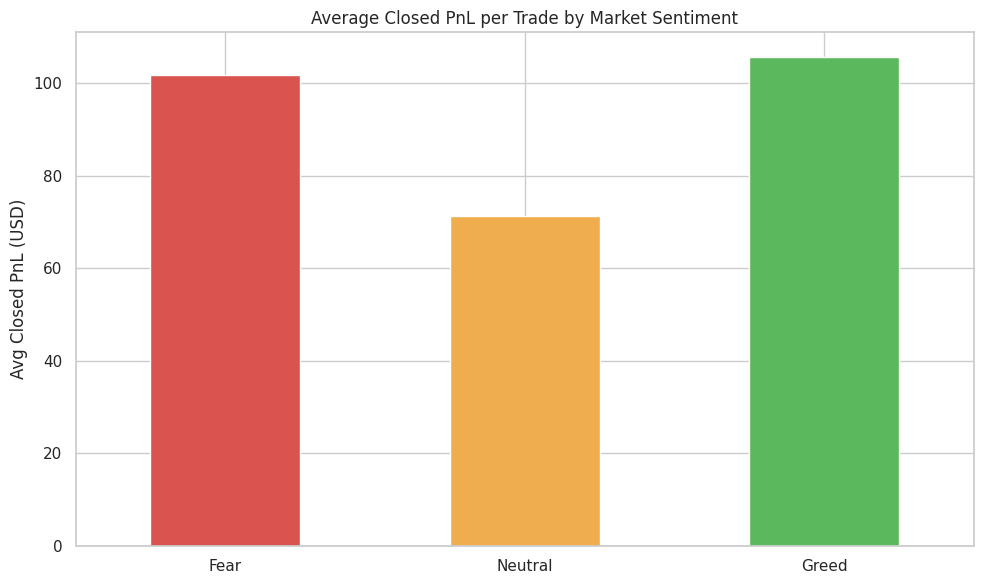

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
os.makedirs("outputs", exist_ok=True)

colors = {"Fear": "#d9534f", "Neutral": "#f0ad4e", "Greed": "#5cb85c"}

#  Average PnL per trade by sentiment (bar chart)
fig, ax = plt.subplots()
perf_by_sentiment["avg_pnl"].plot(kind="bar", ax=ax, color=[colors[s] for s in perf_by_sentiment.index])
ax.set_title("Average Closed PnL per Trade by Market Sentiment")
ax.set_ylabel("Avg Closed PnL (USD)")
ax.set_xlabel("")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/01_avg_pnl_by_sentiment.png", dpi=150)
plt.show()


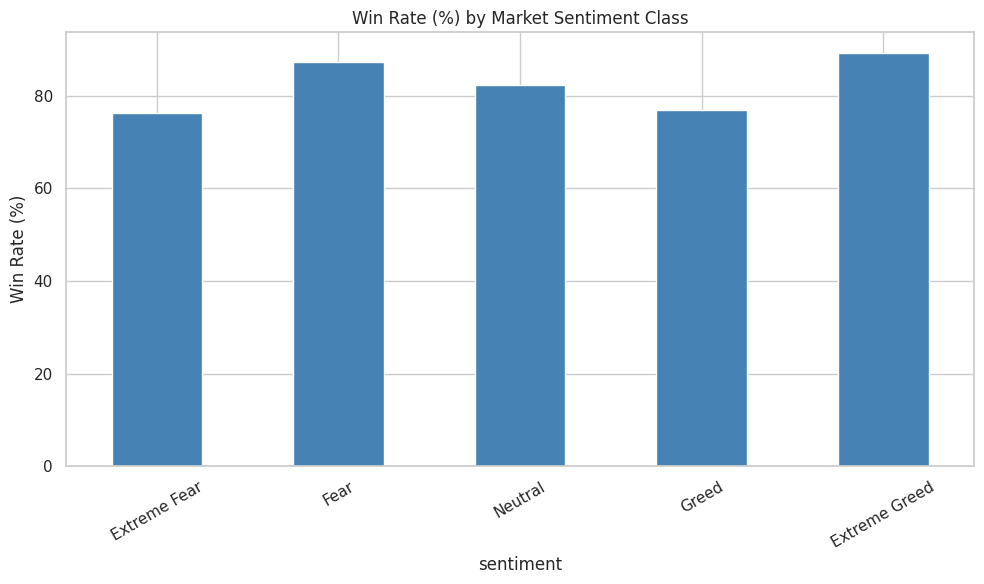

In [ ]:
fig, ax = plt.subplots()
perf_by_class["win_rate"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Win Rate (%) by Market Sentiment Class")
ax.set_ylabel("Win Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/02_winrate_by_sentiment_class.png", dpi=150)
plt.show()

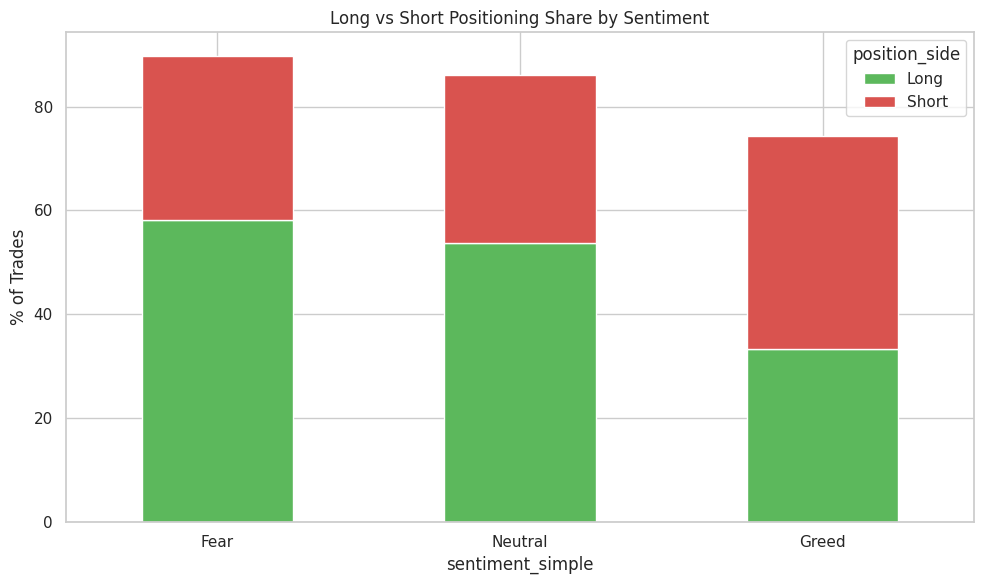

In [ ]:
fig, ax = plt.subplots()
side_mix[["Long", "Short"]].plot(kind="bar", stacked=True, ax=ax, color=["#5cb85c", "#d9534f"])
ax.set_title("Long vs Short Positioning Share by Sentiment")
ax.set_ylabel("% of Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/03_long_short_mix.png", dpi=150)
plt.show()

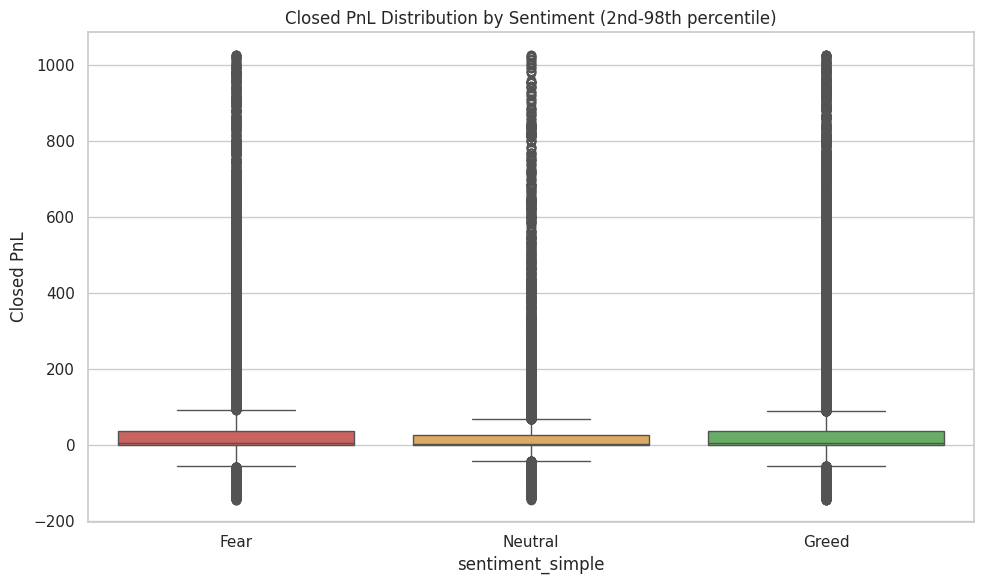

In [ ]:
fig, ax = plt.subplots()
clipped = closed.copy()
lo, hi = clipped["Closed PnL"].quantile([0.02, 0.98])
clipped = clipped[(clipped["Closed PnL"] >= lo) & (clipped["Closed PnL"] <= hi)]
sns.boxplot(data=clipped, x="sentiment_simple", y="Closed PnL", order=order_simple, ax=ax, palette=colors)
ax.set_title("Closed PnL Distribution by Sentiment (2nd-98th percentile)")
plt.tight_layout()
plt.savefig("outputs/04_pnl_distribution_boxplot.png", dpi=150)
plt.show()


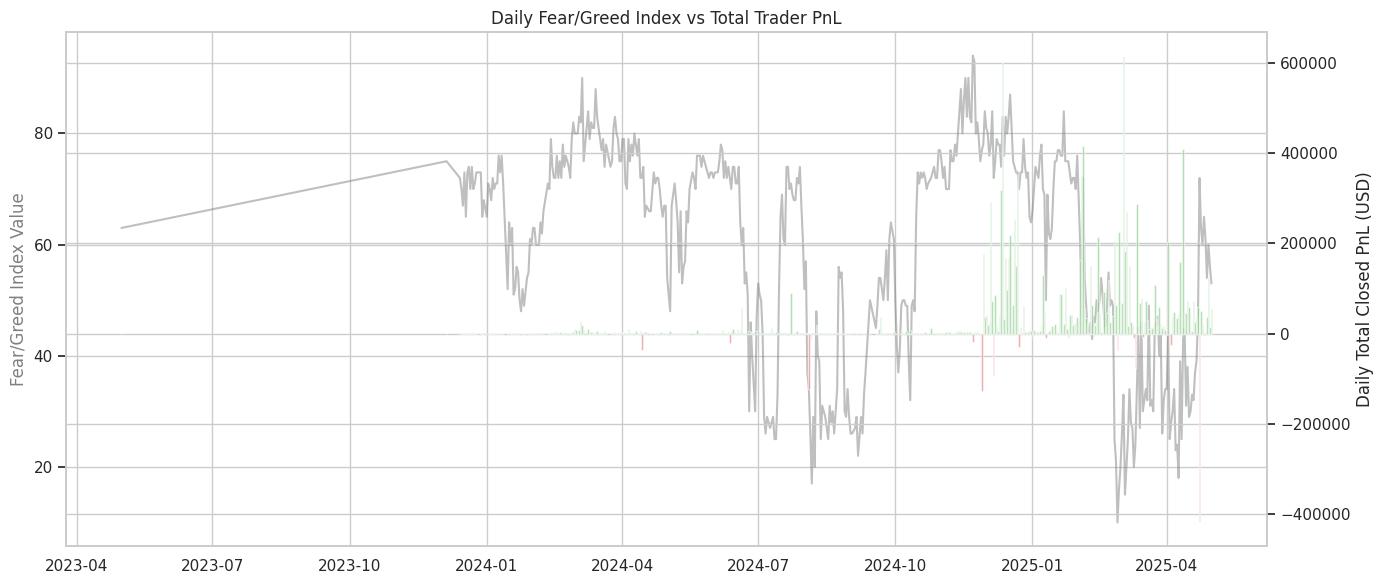

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(daily["date"], daily["fg_value"], color="gray", alpha=0.5, label="Fear/Greed Index")
ax2.bar(daily["date"], daily["daily_pnl"],
        color=np.where(daily["daily_pnl"] >= 0, "#5cb85c", "#d9534f"), alpha=0.6, width=1)
ax1.set_ylabel("Fear/Greed Index Value", color="gray")
ax2.set_ylabel("Daily Total Closed PnL (USD)")
ax1.set_title("Daily Fear/Greed Index vs Total Trader PnL")
plt.tight_layout()
plt.savefig("outputs/05_daily_sentiment_vs_pnl.png", dpi=150)
plt.show()


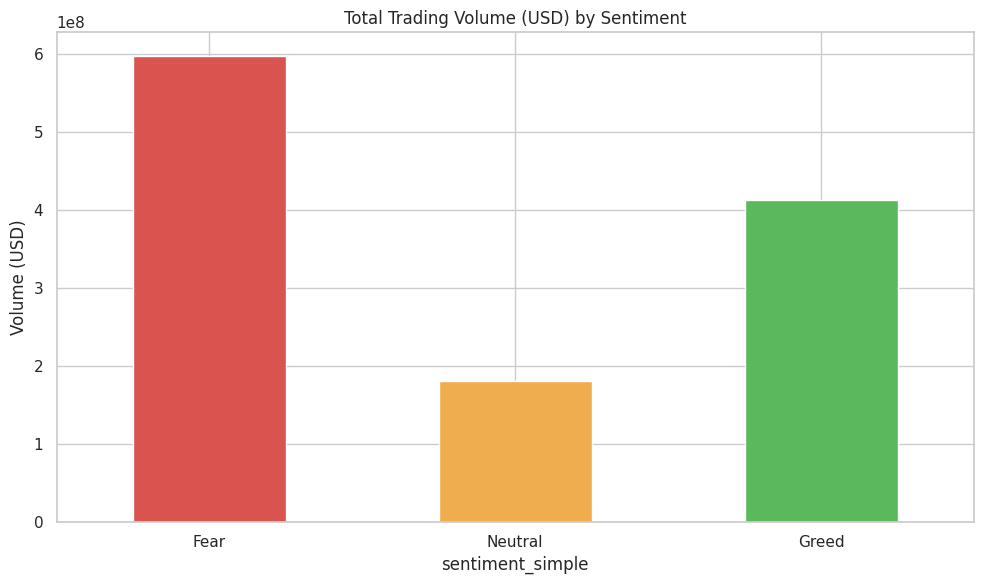

In [ ]:
fig, ax = plt.subplots()
vol_by_sent = df.groupby("sentiment_simple")["Size USD"].sum().reindex(order_simple)
vol_by_sent.plot(kind="bar", ax=ax, color=[colors[s] for s in order_simple])
ax.set_title("Total Trading Volume (USD) by Sentiment")
ax.set_ylabel("Volume (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/06_volume_by_sentiment.png", dpi=150)
plt.show()

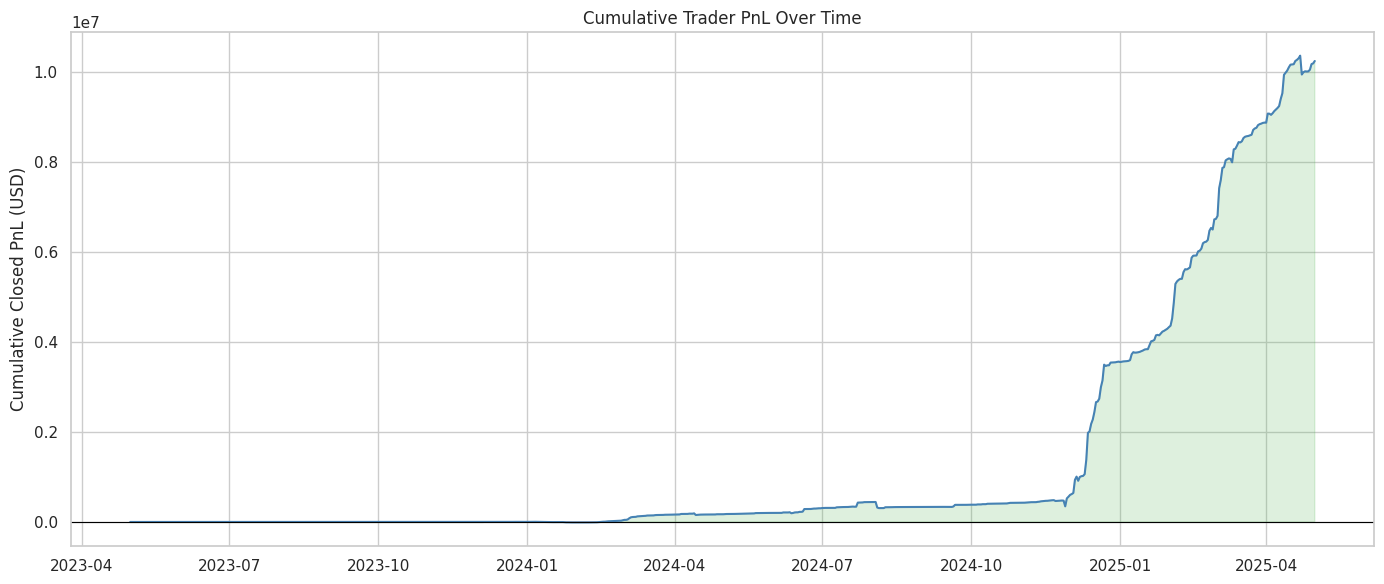

In [ ]:
daily_sorted = daily.sort_values("date").copy()
daily_sorted["cumulative_pnl"] = daily_sorted["daily_pnl"].cumsum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_sorted["date"], daily_sorted["cumulative_pnl"], color="steelblue", linewidth=1.5)
ax.fill_between(daily_sorted["date"], daily_sorted["cumulative_pnl"], 0,
                 where=(daily_sorted["cumulative_pnl"] >= 0), color="#5cb85c", alpha=0.2)
ax.fill_between(daily_sorted["date"], daily_sorted["cumulative_pnl"], 0,
                 where=(daily_sorted["cumulative_pnl"] < 0), color="#d9534f", alpha=0.2)
ax.set_title("Cumulative Trader PnL Over Time")
ax.set_ylabel("Cumulative Closed PnL (USD)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("outputs/07_cumulative_pnl.png", dpi=150)
plt.show()


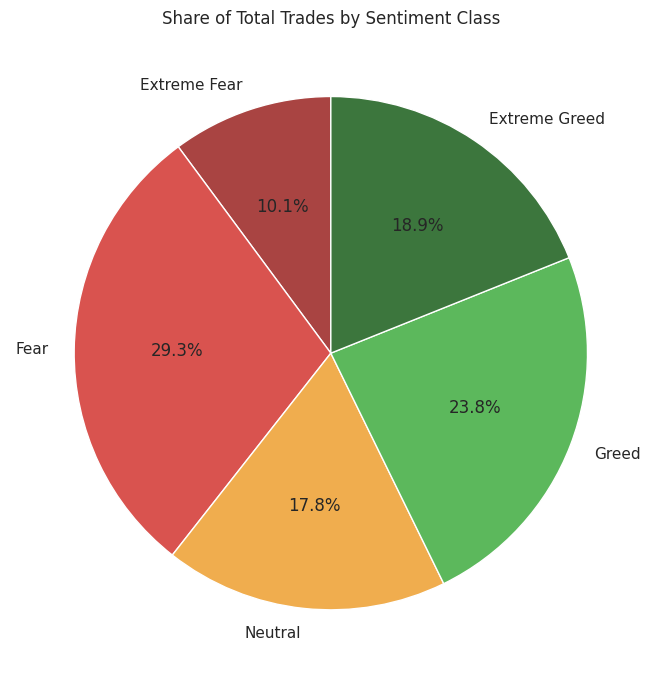

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
trade_counts = df["sentiment"].value_counts().reindex(
    ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
pie_colors = ["#a94442", "#d9534f", "#f0ad4e", "#5cb85c", "#3c763d"]
ax.pie(trade_counts, labels=trade_counts.index, autopct="%1.1f%%",
       colors=pie_colors, startangle=90)
ax.set_title("Share of Total Trades by Sentiment Class")
plt.tight_layout()
plt.savefig("outputs/08_trade_share_pie.png", dpi=150)
plt.show()


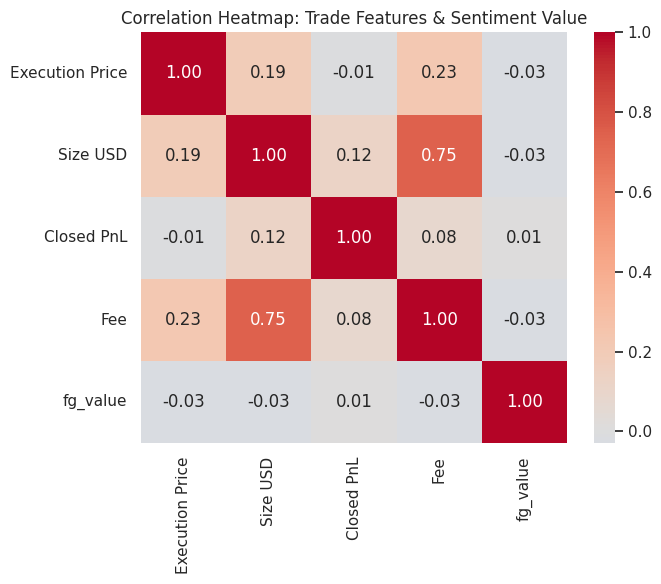

In [ ]:
numeric_cols = ["Execution Price", "Size USD", "Closed PnL", "Fee", "fg_value"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap: Trade Features & Sentiment Value")
plt.tight_layout()
plt.savefig("outputs/09_correlation_heatmap.png", dpi=150)
plt.show()


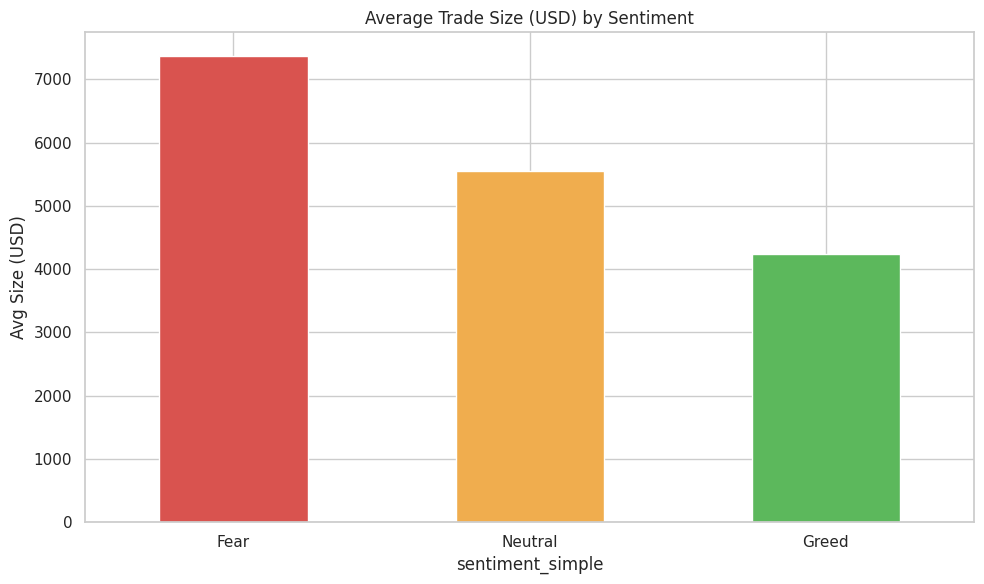

In [ ]:
fig, ax = plt.subplots()
perf_by_sentiment["avg_size_usd"].plot(kind="bar", ax=ax, color=[colors[s] for s in perf_by_sentiment.index])
ax.set_title("Average Trade Size (USD) by Sentiment")
ax.set_ylabel("Avg Size (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/10_avg_trade_size.png", dpi=150)
plt.show()